# **Applied Data Science in Medicine & Psychology - Assignment 10**
## Machine Learning
---
**Deadline: 18.07.2023, 23:59**
### **General setup and submission**
1. Save an editable copy of this notebook to your Google Drive ``File`` $\rightarrow$ ``Save a copy in Drive`` and remove the automatically appended "Copy of" text. **Do not change the file name**.
2. Work on the assignment in the *copied* version of the notebook. Make sure that you **replace** all parts of the tasks indicated with *YOUR CODE HERE* and **raise NotImplementedError()** (otherwise this causes an error in your implementation) or *YOUR ANSWER HERE* with your solution.
3. If you do a break during the implementation, you can save the current status of your work in your repository following the submission instructions below. When you continue working on the assignment, do this in the version of the notebook that you saved in your Google Drive (access from your Google Colab account) or your repository.
4. After finishing the assignment submit your assignment as follows:
    * Check that everything runs as expected. To do that select in the menubar ``Runtime`` $\rightarrow$ ``Restart and run all``. This will clear all your local variables and runs your notebook from the beginning
    * Save your notebook, click ``File`` $\rightarrow$ ``Save``
    * Click ``File`` $\rightarrow$ ``Save a copy in GitHub``
    * Select ``digikolleg-data-science-psychology/10_machine_learning-<username>`` from the Repository drop-down menu 
    * Type ``10_machine_learning.ipynb`` into the File path text box
    * Optionally, you may enter a description into the "Commit message" text box (like: "solved task 1" or "ready for grading")
    * Make sure that the "Include a link to Colaboratory" box is checked
    * Press "Ok"
    * A new tab or window should open up, displaying your submitted notebook within your GitHub repository

Before the assignment deadline, you can re-submit your assignment as often as you would like. This will update the copy of your assignment file in your assignment's repository.

### **Assignment Description**
***General description... TODO***

#### **Assignment goals**
You are going to learn the following things in this assignment:
1. ***TODO***
2. ***TODO***

#### **Assignment point value**
This assignment is worth a total (up to) ***X TODO*** point***(s) TODO***. If your code passes all of the manual and automatic tests you will receive full credit.

### **Tasks**
Make sure that you now work on your *copied* version of this assignment's notebook.

#### 0. Imports and Setup
Please **run** the cell below to import the libraries needed for this assignment.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
!pip install biopsykit
import biopsykit as bp
import seaborn as sns

#### X.

In [ ]:
data_cortisol = bp.example_data.get_saliva_example()
sample_times = [-30, -1, 30, 40, 50, 60, 70]
fig, ax = plt.subplots(figsize=(6, 3))
bp.protocols.plotting.saliva_plot(
    data=data_cortisol, saliva_type="cortisol", sample_times=sample_times, test_times=[0, 30], sample_times_absolute=True,
    test_title="Study Phase", ax=ax,
);

In [ ]:
auc = bp.saliva.auc(
    data_cortisol, saliva_type="cortisol", sample_times=sample_times, compute_auc_post=True, remove_s0=True
)
max_inc = bp.saliva.max_increase(data_cortisol, saliva_type="cortisol", remove_s0=True)
slope = bp.saliva.slope(data_cortisol, sample_idx=[1, 4], sample_times=sample_times, saliva_type="cortisol")

cort_features = pd.concat([auc, max_inc, slope], axis=1)
labels = np.array(cort_features.index.get_level_values(0))
data_analysis = cort_features.droplevel(0, axis=0)
data_analysis.head()

In [ ]:
# run cell to visualize features
data_plot = cort_features.reset_index()
sns.pairplot(data=data_plot, hue="condition")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score#, plot_confusion_matrix

#### 1. Preprocessing

##### 1.1 Scaling

In [ ]:
### BEGIN SOLUTION
def scale_data(data):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    return data_scaled
### END SOLUTION

In [ ]:
res_scaled = scale_data(data_analysis)
assert type(res_scaled) == np.ndarray
assert np.shape(res_scaled) == (26, 5)
assert np.sum(np.std(res_scaled, axis=0)) > 4.99
assert np.abs(np.sum(np.mean(res_scaled, axis=0))) < 1e-10

#### X. Dimensionality Reduction

In [ ]:
### BEGIN SOLUTION
def reduce_dims(data, variance):
    pca = PCA(n_components=variance, svd_solver="full")
    data_pca = pca.fit_transform(data)
    return data_pca
### END SOLUTION

In [ ]:
res_dim_red = reduce_dims(data_analysis, 0.8)
fig, ax = plt.subplots()
ax.scatter(res_dim_red[labels=="Intervention", 0], res_dim_red[labels=="Intervention", 1], label="Intervention")
ax.scatter(res_dim_red[labels=="Control", 0], res_dim_red[labels=="Control", 1], label="Control")
ax.legend()

#### X. Train Test Split -> RENAME?

In [ ]:
def split_data(data, labels, test_size):
    X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=test_size, stratify=labels, random_state=10)
    return X_train, X_test, Y_train, Y_test

In [ ]:
X_train, X_test, Y_train, Y_test = split_data(data_analysis, labels, 0.3)

In [ ]:
clf = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(clf, X_train, Y_train, cv=5)
scores

In [ ]:
np.mean(scores)

In [ ]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X=X_train, y=Y_train)

In [ ]:
clf.score(X_train, Y_train)

In [ ]:
clf.score(X_test, Y_test)

#### X. Regression

#### X. Clustering

#### X. Classification

##### X.X Without Model Selection (without Crossvalidation)

##### X.X With Model Selection (with Crossvalidation)

In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score#, plot_confusion_matrix

#### 1. Preprocessing

##### 1.1 Scaling

In [69]:
### BEGIN SOLUTION
def scale_data(data):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    return data_scaled
### END SOLUTION

In [86]:
res_scaled = scale_data(data_analysis)
assert type(res_scaled) == np.ndarray
assert np.shape(res_scaled) == (26, 5)
assert np.sum(np.std(res_scaled, axis=0)) > 4.99
assert np.abs(np.sum(np.mean(res_scaled, axis=0))) < 1e-10

#### X. Dimensionality Reduction

In [109]:
### BEGIN SOLUTION
def reduce_dims(data, variance):
    pca = PCA(n_components=variance, svd_solver="full")
    data_pca = pca.fit_transform(data)
    return data_pca
### END SOLUTION

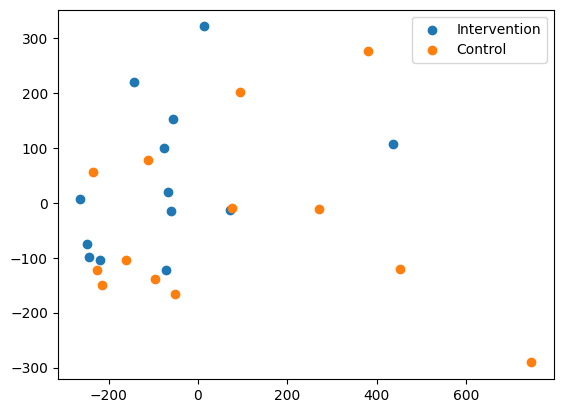

In [128]:
res_dim_red = reduce_dims(data_analysis, 0.8)
fig, ax = plt.subplots()
ax.scatter(res_dim_red[labels=="Intervention", 0], res_dim_red[labels=="Intervention", 1], label="Intervention")
ax.scatter(res_dim_red[labels=="Control", 0], res_dim_red[labels=="Control", 1], label="Control")
ax.legend()

#### X. Train Test Split -> RENAME?

In [122]:
def split_data(data, labels, test_size):
    X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=test_size, stratify=labels, random_state=10)
    return X_train, X_test, Y_train, Y_test

In [132]:
X_train, X_test, Y_train, Y_test = split_data(data_analysis, labels, 0.3)

In [140]:
clf = RandomForestClassifier(n_estimators=100)
scores = cross_val_score(clf, X_train, Y_train, cv=5)
scores

array([0.5       , 0.5       , 0.75      , 0.33333333, 0.33333333])

In [141]:
np.mean(scores)

0.4833333333333334

In [135]:
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X=X_train, y=Y_train)

RandomForestClassifier()

In [138]:
clf.score(X_train, Y_train)

1.0

In [139]:
clf.score(X_test, Y_test)

0.625

#### X. Regression

#### X. Clustering

#### X. Classification

##### X.X Without Model Selection (without Crossvalidation)

##### X.X With Model Selection (with Crossvalidation)